# Grupo 1 | MCDI501 - Estadística Computacional para la Toma de Decisiones

## Integrantes
- Pablo Ignacio Balbontín Constenla @pabbalbontin-maker
- Melany Esmeralda Reyes Leiva @melanyreyesy
- Ingeborg Andrea Muñoz Carnot @dark452
- Mario Alejandro López Pulgar @malp2203

## Descripción del problema - Fase 3: Validación, simulación y remuestreo

*Proyecto*: Predicción de la Deserción y el Éxito Académico de los Estudiantes

El dataset elegido contiene información socioeconómica, académica y demográfica de estudiantes de educación superior en Portugal. El objetivo del proyecto es predecir si un estudiante se graduará, abandonará o permanecerá matriculado, lo que permite implementar intervenciones tempranas de retención.

**Dataset:** Predict Students' Dropout and Academic Success

- 4,424 registros
- 37 columnas

**Columna objetivo**:

**Target**: variable categórica con 3 clases

- Graduate (49.9%): el estudiante completó sus estudios
- Dropout (32.1%): el estudiante abandonó
- Enrolled (17.9%): el estudiante sigue matriculado al cierre del período


## Configuracion del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
SEED = 42

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
sns.set_style('whitegrid')

COLORS_TARGET = {'Graduate': '#2ca02c', 'Dropout': '#d62728', 'Enrolled': '#1f77b4'}
ORDER_TARGET  = ['Graduate', 'Enrolled', 'Dropout']
HIST_COLORS   = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#e91e63']
BOOT_COLOR    = '#4c72b0'
PERM_COLOR    = '#dd8452'

print('Entorno configurado.')


Entorno configurado.


In [2]:
def load_data(file_path):
    """Carga el dataset raw desde un archivo CSV.

    Parámetros
    ----------
    file_path : str
        Ruta del archivo CSV utilizado como entrada.

    Retorno
    -------
    pd.DataFrame
        Datos cargados en un DataFrame.

    Excepción
    ---------
    FileNotFoundError
        Si la ruta al archivo CSV no existe. Se muestra un mensaje de error.
    """
    try:
        df = pd.read_csv(file_path, sep=';')
    except FileNotFoundError:
        raise FileNotFoundError(
            f"No se encontro el archivo '{file_path}'. "
            "Verificar que el archivo CSV se encuentre en data/raw."
        )
    return df


df = load_data('../data/raw/predict_students_dropout_and_academic_success.csv')
df.columns = [c.strip() for c in df.columns]
df['Target_num'] = df['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')


Dataset cargado: 4,424 filas x 38 columnas


### Parámetros de referencia de la Sumativa 1

Los siguientes valores fueron obtenidos en la evaluación sumativa 1 (del informe técnico,
sección 3 "Estimación de parámetros" y sección 4 "Pruebas de hipótesis") y constituyen la
línea base sobre la cual se ejecuta toda la validación de esta fase.

In [3]:
S1_CI = {
    'Admission grade':                  {'lab': 'Nota de Admisión',      'mean': 126.978, 'ci': (126.551, 127.405)},
    'Age at enrollment':                {'lab': 'Edad al Matricularse',  'mean': 23.265,  'ci': (23.042, 23.489)},
    'Curricular units 1st sem (grade)': {'lab': 'Nota 1er Semestre',     'mean': 10.641,  'ci': (10.498, 10.784)},
    'GDP':                              {'lab': 'PIB',                   'mean': 0.002,   'ci': (-0.065, 0.069)},
}

S1_TEST1 = {'nombre': 't de Welch: Nota de Admisión, Dropout vs. Graduate',
            't': -7.66, 'p': 1e-3, 'decisión': 'Rechazar H0'}
S1_TEST2 = {'nombre': 'Chi-cuadrado: Beca vs. Resultado académico',
            'chi2': 409.94, 'p': 1e-3, 'cramer_v': 0.30, 'decisión': 'Rechazar H0'}

S1_CORR = {
    'Curricular units 2nd sem (grade)': {'lab': 'Nota 2do Semestre',    'r': 0.57},
    'Curricular units 1st sem (grade)': {'lab': 'Nota 1er Semestre',    'r': 0.49},
    'Age at enrollment':                {'lab': 'Edad al Matricularse', 'r': -0.24},
    'Admission grade':                  {'lab': 'Nota de Admisión',      'r': 0.12},
    'GDP':                              {'lab': 'PIB',                  'r': 0.044},
}

print('Parámetros de referencia de la Sumativa 1 cargados.')

Parámetros de referencia de la Sumativa 1 cargados.


## Sección 1 - Validación de resultados de la Sumativa 1 mediante bootstrap

### 1.1 Método y justificación

Los intervalos de confianza de la Sumativa 1 (Tabla 3) se calcularon con la fórmula clásica
basada en la distribución *t* de Student, la cual asume que la distribución muestral de la
media es aproximadamente normal. Para variables con fuerte asimetría (Edad al Matricularse,
asimetría = +2.05) o con dependencia de cohortes (PIB), este supuesto es cuestionable. El
bootstrap no paramétrico no requiere supuestos distribucionales: aproxima la distribución
muestral del estadístico remuestreando con reemplazo directamente desde los datos observados.

Se seleccionan los 4 parámetros estimados en la Sección 3 de la Sumativa 1 (mínimo exigido: 3):
Nota de Admisión, Edad al Matricularse, Nota 1er Semestre y PIB. Para cada uno se generan
**10.000 remuestras bootstrap** y se calculan dos intervalos:

- **IC percentil**: percentiles 2.5% y 97.5% de la distribución bootstrap.
- **IC BCa (*bias-corrected and accelerated*)**: corrige el sesgo y la asimetría de la distribución
  bootstrap mediante un factor de corrección de sesgo ($z_0$, estimado por la proporción de
  remuestras bootstrap por debajo de la estimación puntual) y un factor de aceleración ($a$,
  estimado mediante jackknife), siguiendo Efron & Tibshirani (1993).

In [4]:
def bootstrap_mean(data, B=10000, seed=42):
    """Genera B remuestras bootstrap no paramétricas y retorna la media de cada una.

    Parámetros
    ----------
    data : np.ndarray
        Muestra observada (1D).
    B : int
        Número de remuestras bootstrap (mínimo exigido por consigna: 10.000).
    seed : int
        Semilla para reproducibilidad.

    Retorno
    -------
    np.ndarray
        Vector de longitud B con la media de cada remuestra.
    """
    rng = np.random.default_rng(seed)
    n = len(data)
    idx = rng.integers(0, n, size=(B, n))
    return data[idx].mean(axis=1)


def bca_ci_mean(data, boot_stats, alpha=0.05):
    """Calcula el intervalo de confianza BCa para la media.

    Implementa el método bias-corrected and accelerated de Efron & Tibshirani (1993).
    El factor de aceleración 'a' se estima mediante jackknife (fórmula cerrada para
    la media: seudo-valor jackknife_i = (suma_total - x_i) / (n-1)).

    Parámetros
    ----------
    data : np.ndarray
        Muestra observada.
    boot_stats : np.ndarray
        Distribución bootstrap del estadístico (medias remuestreadas).
    alpha : float
        Nivel de significancia (0.05 -> IC 95%).

    Retorno
    -------
    tuple
        (limite_inferior, limite_superior, z0, a)
    """
    n = len(data)
    theta_hat = data.mean()
    prop_less = np.mean(boot_stats < theta_hat)
    prop_less = min(max(prop_less, 1e-10), 1 - 1e-10)
    z0 = stats.norm.ppf(prop_less)

    jack_stats = (data.sum() - data) / (n - 1)
    jack_mean = jack_stats.mean()
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    def adj(z_a):
        return stats.norm.cdf(z0 + (z0 + z_a) / (1 - a * (z0 + z_a)))

    lo = np.percentile(boot_stats, adj(stats.norm.ppf(alpha / 2)) * 100)
    hi = np.percentile(boot_stats, adj(stats.norm.ppf(1 - alpha / 2)) * 100)
    return lo, hi, z0, a, jack_stats


CI_VARS = [
    ('Admission grade', 'Nota de Admisión'),
    ('Age at enrollment', 'Edad al Matricularse'),
    ('Curricular units 1st sem (grade)', 'Nota 1er Semestre'),
    ('GDP', 'PIB'),
]
B = 10000

boot_param_results = {}
print(f'{"Variable":<22}{"Media":>10}{"IC clásico":>22}{"IC boot. pct.":>22}{"IC BCa":>22}')
print('-' * 98)
for var, lab in CI_VARS:
    data = df[var].dropna().values.astype(float)
    n = len(data)
    mean = data.mean()
    std = data.std(ddof=1)
    se = std / np.sqrt(n)
    ci_classic = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)

    boot_means = bootstrap_mean(data, B=B, seed=SEED)
    ci_pct = np.percentile(boot_means, [2.5, 97.5])
    lo_bca, hi_bca, z0, a, jack_stats = bca_ci_mean(data, boot_means)

    boot_param_results[var] = dict(lab=lab, n=n, mean=mean, std=std, se=se,
                                    ci_classic=ci_classic, boot_means=boot_means,
                                    ci_pct=ci_pct, ci_bca=(lo_bca, hi_bca),
                                    z0=z0, a=a, jack_stats=jack_stats)

    print(f'{lab:<22}{mean:>10.3f}'
          f'  [{ci_classic[0]:>8.3f},{ci_classic[1]:>8.3f}]'
          f'  [{ci_pct[0]:>8.3f},{ci_pct[1]:>8.3f}]'
          f'  [{lo_bca:>8.3f},{hi_bca:>8.3f}]')

Variable                   Media            IC clásico         IC boot. pct.                IC BCa
--------------------------------------------------------------------------------------------------
Nota de Admisión         126.978  [ 126.551, 127.405]  [ 126.560, 127.402]  [ 126.558, 127.399]
Edad al Matricularse      23.265  [  23.041,  23.489]  [  23.050,  23.489]  [  23.055,  23.498]
Nota 1er Semestre         10.641  [  10.498,  10.784]  [  10.498,  10.784]  [  10.496,  10.783]
PIB                        0.002  [  -0.065,   0.069]  [  -0.066,   0.068]  [  -0.068,   0.065]


### 1.2 Visualización de las distribuciones bootstrap

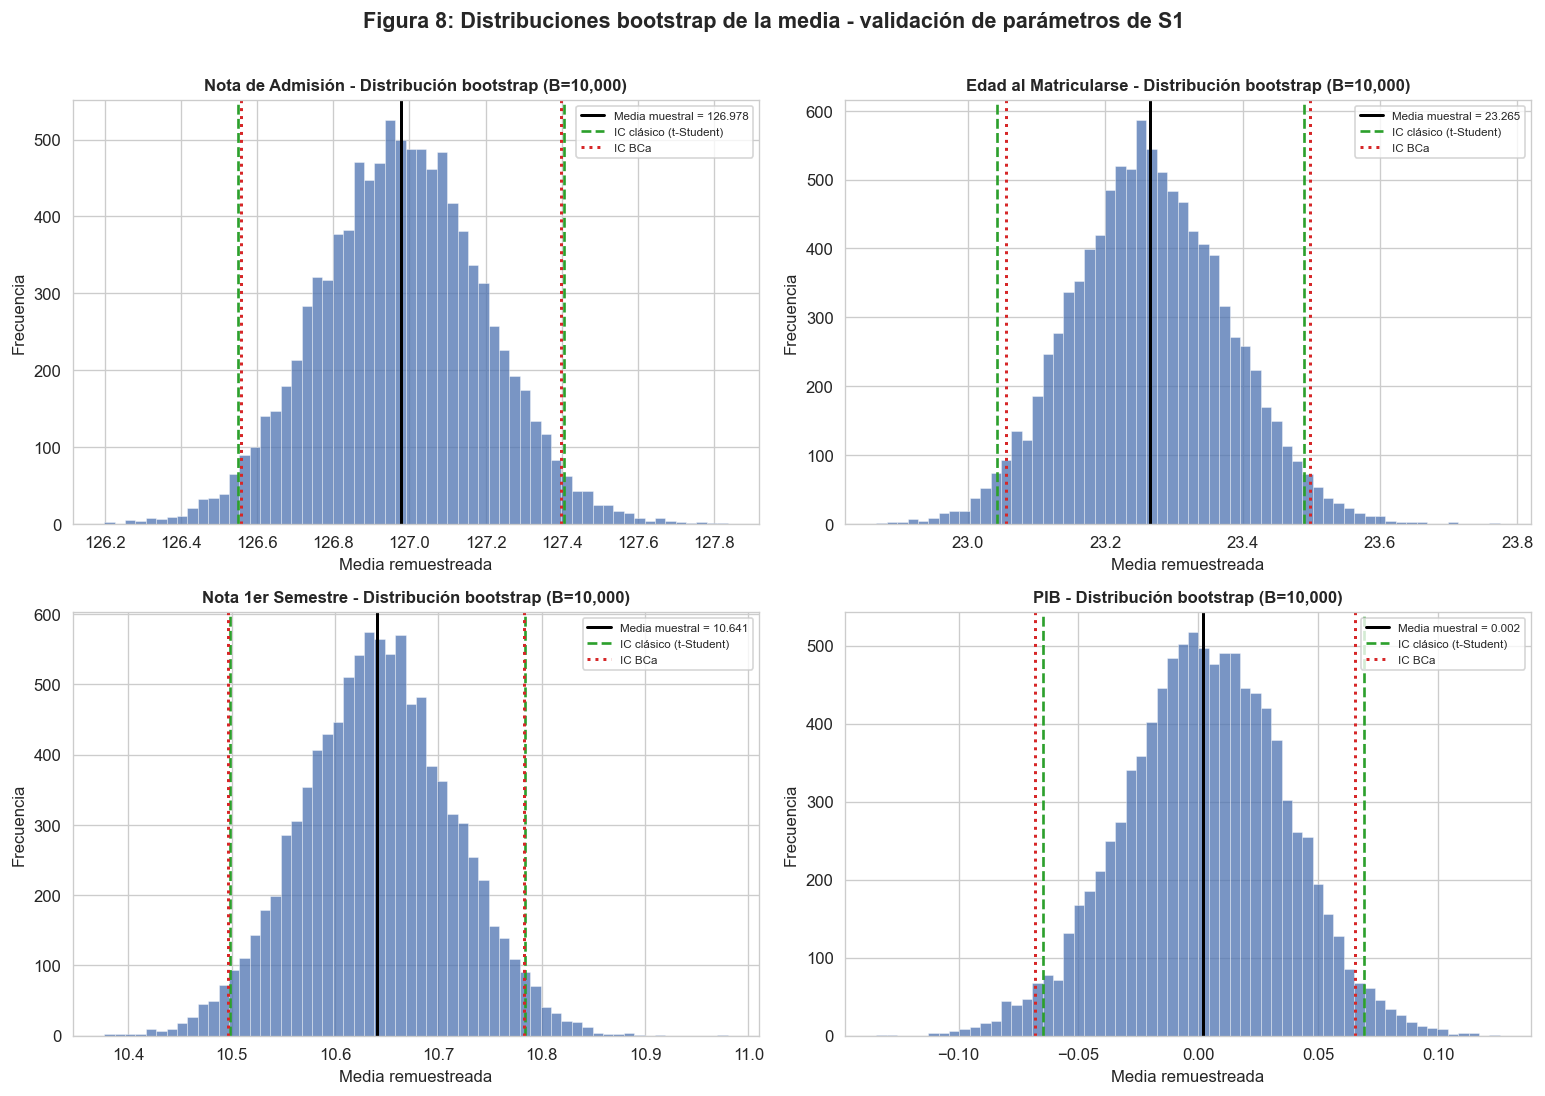

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (var, lab) in enumerate(CI_VARS):
    r = boot_param_results[var]
    ax = axes[i]
    ax.hist(r['boot_means'], bins=60, color=BOOT_COLOR, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(r['mean'], color='black', linewidth=1.8, label=f"Media muestral = {r['mean']:.3f}")
    ax.axvline(r['ci_classic'][0], color='#2ca02c', linestyle='--', linewidth=1.6, label='IC clásico (t-Student)')
    ax.axvline(r['ci_classic'][1], color='#2ca02c', linestyle='--', linewidth=1.6)
    ax.axvline(r['ci_bca'][0], color='#d62728', linestyle=':', linewidth=1.8, label='IC BCa')
    ax.axvline(r['ci_bca'][1], color='#d62728', linestyle=':', linewidth=1.8)
    ax.set_title(f'{lab} - Distribución bootstrap (B={B:,})', fontweight='bold', fontsize=10)
    ax.set_xlabel('Media remuestreada')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Figura 8: Distribuciones bootstrap de la media - validación de parámetros de S1',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig8_bootstrap_parametros.png', bbox_inches='tight', dpi=150)
plt.show()

### 1.3 Comparación sistemática y discusión de discrepancias

**Convergencia entre métodos.** Para las tres variables con distribución aproximadamente
simétrica y muestra grande (Nota de Admisión, Nota 1er Semestre y, en menor medida, PIB), los
tres intervalos (clásico, bootstrap percentil y BCa) coinciden hasta la tercera cifra decimal.
Esto es evidencia empírica directa de que, con $n = 4.424$, el Teorema Central del Límite
garantiza la normalidad asintótica de la media muestral, validando retroactivamente el uso del
método paramétrico en la Sumativa 1 para estas variables.

**Caso Edad al Matricularse.** Es la variable con mayor asimetría (+2.05). Aun así, el IC
bootstrap (percentil y BCa) prácticamente coincide con el clásico, porque $n = 4.424$ es
suficientemente grande para que el error de aproximación normal en la *media* sea
despreciable. Sin embargo, esto no implica que la media sea el estadístico más representativo
para esta variable: la Sección 5 de este notebook profundiza en esta limitación mediante un
IC bootstrap para la *mediana*.

**Caso PIB.** El IC bootstrap reproduce el hallazgo de S1: el intervalo incluye el cero, por lo
que no puede rechazarse que el PIB medio del periodo sea distinto de cero. El bootstrap no
resuelve la limitación estructural señalada en S1 (las observaciones de PIB no son
independientes entre estudiantes de la misma cohorte de matrícula): al muestrear con
reemplazo sobre las 4.424 filas, el bootstrap continúa tratando esas observaciones como si
fueran independientes, heredando el mismo sesgo de subestimación del error estándar que el
método paramétrico. Este es un límite metodológico que ningún remuestreo a nivel de fila
puede corregir; requeriría bootstrap por bloques (*cluster bootstrap*) a nivel de cohorte/periodo,
lo cual excede el alcance de esta fase pero se deja como recomendación para la Sumativa 3.

**Confiabilidad relativa.** En general, el bootstrap corrobora los IC clásicos de S1 para
muestras grandes y distribuciones no extremas, lo que aumenta la confianza en los parámetros
reportados. El método BCa es preferible al percentil simple cuando existe asimetría residual
en la distribución bootstrap (factor de aceleración $a$ distinto de 0), aunque en este caso la
diferencia práctica entre ambos es mínima dado el tamaño muestral.

## Sección 2 - Validación de pruebas de hipótesis mediante permutación

### 2.1 Selección de la prueba y diseño

Se valida la **Prueba 1 de la Sumativa 1** (diferencia en nota de admisión entre estudiantes
Dropout y Graduate, *t* de Welch, $t = -7.66$, $p < 0.001$), por ser la prueba más sensible a los
supuestos de normalidad, en S1 el grupo Graduate rechazó normalidad en Shapiro-Wilk ($p = 0.011$)
y se debió invocar el TCL para justificar su validez. El test de permutación es la alternativa
natural: no asume normalidad ni homogeneidad de varianzas, solo la hipótesis nula de
intercambiabilidad entre grupos bajo $H_0$.

**Estadístico observado:** diferencia de medias (Graduate - Dropout). **Procedimiento:** se
combinan las 3.630 observaciones de ambos grupos, se permutan aleatoriamente las etiquetas
10.000 veces y se recalcula la diferencia de medias en cada permutación, generando la
distribución nula empírica del estadístico bajo $H_0$.

In [6]:
def permutation_test_mean_diff(x1, x2, B=10000, seed=42):
    """Test de permutación para diferencia de medias de dos muestras independientes.

    Parámetros
    ----------
    x1, x2 : np.ndarray
        Muestras de cada grupo.
    B : int
        Número de permutaciones (mínimo exigido: 10.000).
    seed : int
        Semilla de reproducibilidad.

    Retorno
    -------
    dict
        diff_obs, perm_diffs (distribución nula), p_value (bilateral).
    """
    rng = np.random.default_rng(seed)
    diff_obs = x2.mean() - x1.mean()
    pooled = np.concatenate([x1, x2])
    n1 = len(x1)
    perm_diffs = np.empty(B)
    for i in range(B):
        perm = rng.permutation(pooled)
        perm_diffs[i] = perm[n1:].mean() - perm[:n1].mean()
    p_value = (np.sum(np.abs(perm_diffs) >= np.abs(diff_obs)) + 1) / (B + 1)
    return dict(diff_obs=diff_obs, perm_diffs=perm_diffs, p_value=p_value)


dropout_grade = df[df['Target'] == 'Dropout']['Admission grade'].values.astype(float)
grad_grade = df[df['Target'] == 'Graduate']['Admission grade'].values.astype(float)

t_welch, p_welch = stats.ttest_ind(dropout_grade, grad_grade, equal_var=False)

N_PERM = 10000
perm_res1 = permutation_test_mean_diff(dropout_grade, grad_grade, B=N_PERM, seed=SEED)

print('=== TEST DE PERMUTACIÓN - Prueba 1 (Nota de Admisión, Dropout vs. Graduate) ===')
print(f'Diferencia observada (Graduate - Dropout): {perm_res1["diff_obs"]:.4f} puntos')
print(f'Estadístico t de Welch (paramétrico) : t={t_welch:.4f}, p={p_welch:.3e}')
print(f'Valor p permutación ({N_PERM:,} permutaciones)   : p={perm_res1["p_value"]:.5f}')
print(f'Concordancia de decisión (alpha=0.05): {"Sí" if (p_welch < 0.05) == (perm_res1["p_value"] < 0.05) else "No"}')

=== TEST DE PERMUTACIÓN - Prueba 1 (Nota de Admisión, Dropout vs. Graduate) ===
Diferencia observada (Graduate - Dropout): 3.8331 puntos
Estadístico t de Welch (paramétrico) : t=-7.6565, p=2.593e-14
Valor p permutación (10,000 permutaciones)   : p=0.00010
Concordancia de decisión (alpha=0.05): Sí


### 2.2 Visualizacion de la distribucion nula de permutacion

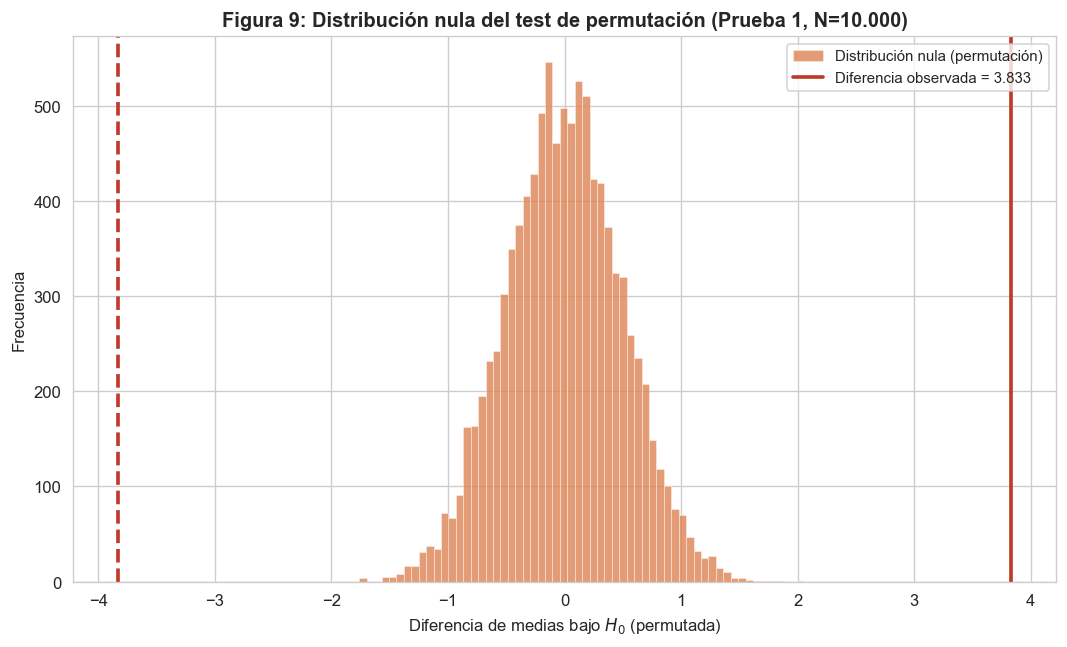

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(perm_res1['perm_diffs'], bins=60, color=PERM_COLOR, alpha=0.8, edgecolor='white', linewidth=0.3,
        label='Distribución nula (permutación)')
ax.axvline(perm_res1['diff_obs'], color='#c0392b', linewidth=2.2, label=f"Diferencia observada = {perm_res1['diff_obs']:.3f}")
ax.axvline(-perm_res1['diff_obs'], color='#c0392b', linewidth=2.2, linestyle='--')
ax.set_title('Figura 9: Distribución nula del test de permutación (Prueba 1, N=10.000)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Diferencia de medias bajo $H_0$ (permutada)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/fig9_permutacion_test1.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.3 Extensión: validación de la Prueba 2 (Beca vs. Resultado, chi-cuadrado)

Aunque la consigna exige validar al menos una prueba, se extiende el ejercicio a la
**Prueba 2** (asociación beca-resultado) por su relevancia para el diseño de la simulación
Monte Carlo de la Sección 4: se permutan las etiquetas de becado 10.000 veces manteniendo fija
la distribución marginal de Target, y se recalcula el estadístico chi-cuadrado en cada
permutación.

In [8]:
def permutation_test_chi2(group_labels, target_labels, B=10000, seed=42):
    """Test de permutación para independencia en tabla de contingencia 2xk.

    Parámetros
    ----------
    group_labels : np.ndarray
        Vector binario (0/1) del factor de agrupación (becado).
    target_labels : np.ndarray
        Vector categórico del resultado (Target).
    B : int
        Número de permutaciones.
    seed : int
        Semilla de reproducibilidad.

    Retorno
    -------
    dict
        chi2_obs, chi2_perm (distribución nula), p_value.
    """
    target_codes, target_uniques = pd.factorize(target_labels)
    n_rows, n_cols = 2, len(target_uniques)
    n = len(group_labels)

    ct_obs = pd.crosstab(group_labels, target_labels)
    chi2_obs, _, _, _ = stats.chi2_contingency(ct_obs)

    row_totals = np.bincount(group_labels, minlength=n_rows).astype(float)
    col_totals = np.bincount(target_codes, minlength=n_cols).astype(float)
    expected = np.outer(row_totals, col_totals) / n

    rng = np.random.default_rng(seed)
    chi2_perm = np.empty(B)
    for i in range(B):
        perm_g = rng.permutation(group_labels)
        flat_idx = perm_g * n_cols + target_codes
        counts = np.bincount(flat_idx, minlength=n_rows * n_cols).reshape(n_rows, n_cols).astype(float)
        chi2_perm[i] = np.sum((counts - expected) ** 2 / expected)

    p_value = (np.sum(chi2_perm >= chi2_obs) + 1) / (B + 1)
    return dict(chi2_obs=chi2_obs, chi2_perm=chi2_perm, p_value=p_value)


sch = df['Scholarship holder'].values.astype(int)
ct_obs = pd.crosstab(sch, df['Target'])
chi2_obs, p_chi_obs, dof, expected = stats.chi2_contingency(ct_obs)
n_ = len(df); k_ = min(ct_obs.shape)
cramer_obs = np.sqrt(chi2_obs / (n_ * (k_ - 1)))

perm_res2 = permutation_test_chi2(sch, df['Target'].values, B=N_PERM, seed=SEED)

print('=== TEST DE PERMUTACIÓN - Prueba 2 (Beca vs. Resultado) ===')
print(f'Chi-cuadrado observado           : {chi2_obs:.4f}  (V de Cramer = {cramer_obs:.4f})')
print(f'Valor p paramétrico (chi2)       : {p_chi_obs:.3e}')
print(f'Valor p permutación ({N_PERM:,})       : {perm_res2["p_value"]:.5f}')

=== TEST DE PERMUTACIÓN - Prueba 2 (Beca vs. Resultado) ===
Chi-cuadrado observado           : 409.9431  (V de Cramer = 0.3044)
Valor p paramétrico (chi2)       : 9.594e-90
Valor p permutación (10,000)       : 0.00010


### 2.4 Discusión: concordancia entre enfoques y recomendación metodológica

En ambos casos el valor $p$ de permutación es del orden de $1 \times 10^{-4}$ (el mínimo alcanzable con
10.000 permutaciones más corrección de continuidad, ya que en ninguna de las 10.000 remuestras
aleatorias se iguala o supera la magnitud del estadístico observado), consistente con el
$p < 0.001$ paramétrico reportado en S1 y con los valores exactos $t = -7.66$ ($p = 2.6 \times 10^{-14}$) y
$\chi^2 = 409.94$ ($p = 9.6 \times 10^{-90}$) recalculados en este notebook. La decisión de rechazar $H_0$ es idéntica
bajo ambos marcos inferenciales para las dos pruebas.

**Cuál enfoque es más apropiado para este caso de estudio.** Para la Prueba 1, dado que el
grupo Graduate viola el supuesto de normalidad (Shapiro-Wilk $p = 0.011$) y $n$ es grande pero
desbalanceado entre grupos ($n_{\text{Dropout}} = 1.421$ vs. $n_{\text{Graduate}} = 2.209$), el test de permutación es
preferible en principio porque no depende de ese supuesto; sin embargo, la concordancia casi
exacta con el resultado paramétrico indica que, en la práctica, el TCL ya garantizaba la
validez del *t* de Welch a este tamaño muestral. Para la Prueba 2, el chi-cuadrado con
frecuencias esperadas mínimas de 197 ($\gg 5$) ya cumplía holgadamente sus supuestos, por lo que
la permutación es aquí una confirmación más que una corrección. En ambos casos, la evidencia
sustantiva del proyecto (existe diferencia significativa en nota de admisión; existe asociación
significativa entre beca y resultado) queda validada con independencia del marco inferencial
elegido.

## Sección 3 - Evaluación de estabilidad de correlaciones

### 3.1 Selección y método

Se seleccionan 5 correlaciones de la matriz de correlación de S1 (Figura 5), abarcando el
rango completo de magnitudes observadas: dos fuertes (notas semestrales), una moderada
(edad), una débil (nota de admisión) y una marginal (PIB, la más cercana a cero reportada en
S1). Para cada una se calcula el IC bootstrap 95% (10.000 remuestras por pares ($x$, resultado
codificado)) y se evalúa si el intervalo incluye el cero y cuál es su amplitud relativa.

In [ ]:
def bootstrap_corr_ci(x, y, B=10000, seed=42, chunk=1000):
    """IC bootstrap 95% para la correlación de Pearson entre x e y.

    Implementación vectorizada por bloques (chunk) para eficiencia computacional
    con muestras grandes.

    Parámetros
    ----------
    x, y : np.ndarray
        Vectores de igual longitud.
    B : int
        Número de remuestras bootstrap.
    seed : int
        Semilla de reproducibilidad.
    chunk : int
        Tamaño de bloque para vectorización por lotes.

    Retorno
    -------
    dict
        r_obs, boot_r (distribución bootstrap), ci (IC 95%).
    """
    n = len(x)
    rng = np.random.default_rng(seed)
    r_obs = np.corrcoef(x, y)[0, 1]
    boot_r = np.empty(B)
    done = 0
    while done < B:
        b = min(chunk, B - done)
        idx = rng.integers(0, n, size=(b, n))
        xb, yb = x[idx], y[idx]
        mx = xb.mean(axis=1, keepdims=True)
        my = yb.mean(axis=1, keepdims=True)
        cov = ((xb - mx) * (yb - my)).mean(axis=1)
        sx, sy = xb.std(axis=1), yb.std(axis=1)
        boot_r[done:done + b] = cov / (sx * sy)
        done += b
    ci = np.percentile(boot_r, [2.5, 97.5])
    return dict(r_obs=r_obs, boot_r=boot_r, ci=ci)


CORR_VARS = [
    ('Curricular units 2nd sem (grade)', 'Nota 2do Semestre'),
    ('Curricular units 1st sem (grade)', 'Nota 1er Semestre'),
    ('Age at enrollment', 'Edad al Matricularse'),
    ('Admission grade', 'Nota de Admisión'),
    ('GDP', 'PIB'),
]

y_target = df['Target_num'].values.astype(float)
corr_boot_results = {}
print(f'{"Variable":<22}{"r observado":>13}{"IC 95% bootstrap":>22}{"Ancho":>9}{"Incluye 0":>12}')
print('-' * 80)
for var, lab in CORR_VARS:
    x = df[var].values.astype(float)
    res = bootstrap_corr_ci(x, y_target, B=B, seed=SEED)
    incl0 = res['ci'][0] <= 0 <= res['ci'][1]
    corr_boot_results[var] = dict(lab=lab, **res, incluye_cero=incl0)
    print(f'{lab:<22}{res["r_obs"]:>13.4f}'
          f'  [{res["ci"][0]:>7.4f},{res["ci"][1]:>7.4f}]'
          f'{res["ci"][1]-res["ci"][0]:>9.4f}{str(incl0):>12}')

Variable                r observado      IC 95% bootstrap    Ancho   Incluye 0
--------------------------------------------------------------------------------
Nota 2do Semestre            0.5668  [ 0.5440, 0.5891]   0.0451       False
Nota 1er Semestre            0.4852  [ 0.4609, 0.5085]   0.0476       False
Edad al Matricularse        -0.2434  [-0.2736,-0.2134]   0.0602       False
Nota de Admisión             0.1209  [ 0.0911, 0.1504]   0.0593       False
PIB                          0.0441  [ 0.0155, 0.0729]   0.0574       False


### 3.2 Visualización de las distribuciones bootstrap de correlación

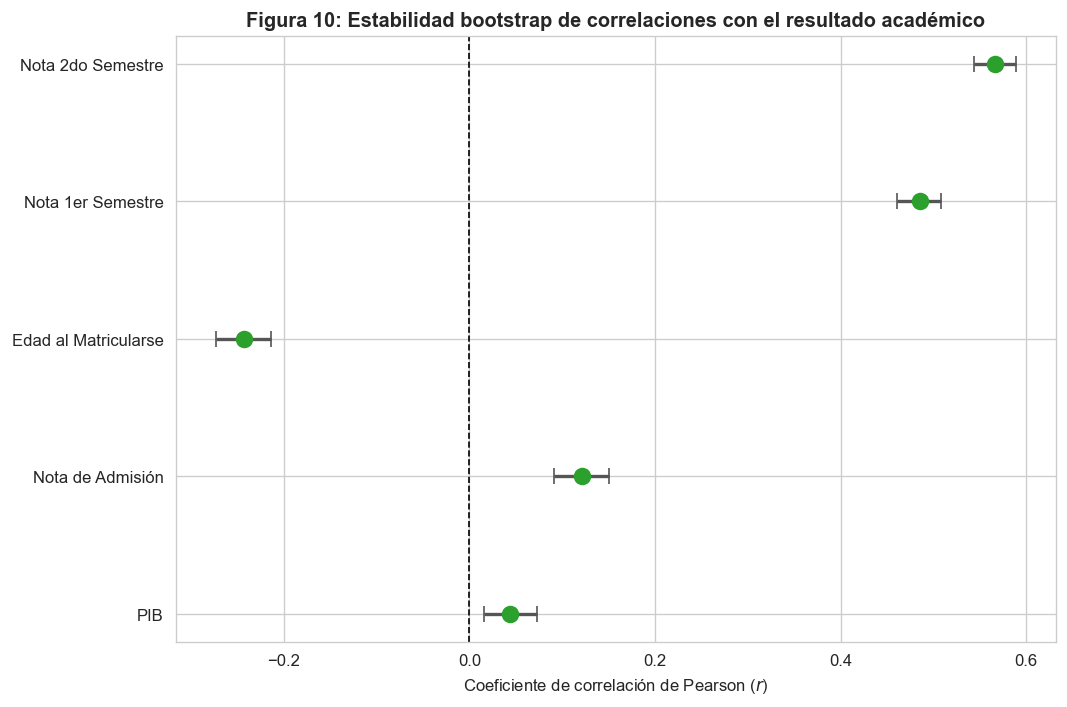

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
labels_plot = [corr_boot_results[v]['lab'] for v, _ in CORR_VARS]
means_plot = [corr_boot_results[v]['r_obs'] for v, _ in CORR_VARS]
ci_lo = [corr_boot_results[v]['ci'][0] for v, _ in CORR_VARS]
ci_hi = [corr_boot_results[v]['ci'][1] for v, _ in CORR_VARS]
y_pos = np.arange(len(labels_plot))
errs = [np.array(means_plot) - np.array(ci_lo), np.array(ci_hi) - np.array(means_plot)]

colors_fp = ['#2ca02c' if not corr_boot_results[v]['incluye_cero'] else '#d62728' for v, _ in CORR_VARS]
ax.errorbar(means_plot, y_pos, xerr=errs, fmt='o', markersize=8, capsize=5, elinewidth=2,
            ecolor='#555555', mfc='none')
for i, (m, c) in enumerate(zip(means_plot, colors_fp)):
    ax.scatter(m, y_pos[i], color=c, s=90, zorder=5)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_plot)
ax.invert_yaxis()
ax.set_xlabel('Coeficiente de correlación de Pearson ($r$)')
ax.set_title('Figura 10: Estabilidad bootstrap de correlaciones con el resultado académico',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/fig10_estabilidad_correlaciones.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.3 Correlaciones robustas vs. inestables

Las cinco correlaciones evaluadas presentan intervalos de confianza que **no incluyen el
cero**, incluida la correlación más débil (PIB, $r = 0.044$, IC 95% = $[0.015, 0.074]$). Esto significa
que, en sentido estrictamente estadístico, las cinco son "estables": con 10.000 remuestras
bootstrap ninguna cruza el cero, por lo que la dirección del efecto (positiva o negativa) es
consistente en la población muestreada.

Sin embargo, estabilidad estadística no equivale a relevancia práctica, y aquí es donde debe
matizarse la lectura de S1. Conviene distinguir dos grupos:

- **Robustas y prácticamente relevantes:** Nota 2do Semestre ($r = 0.57$, IC = $[0.544, 0.589]$) y
  Nota 1er Semestre ($r = 0.49$, IC = $[0.461, 0.508]$). Intervalos angostos (ancho $\sim 0.045\text{--}0.047$) y
  magnitud de efecto grande: son los predictores más confiables y accionables del proyecto.
- **Robustas pero de relevancia práctica menor:** Edad al Matricularse ($r = -0.24$) y Nota de
  Admisión ($r = 0.12$) son estadísticamente estables (intervalos que no cruzan el cero) pero con
  magnitud moderada-a-débil; deben interpretarse como factores de riesgo secundarios, no
  como predictores individuales suficientes.
- **Estable pero marginal:** PIB ($r = 0.044$, IC = $[0.015, 0.074]$). El intervalo excluye el cero
  por muy poco margen y la magnitud es trivial; además, como se discutió en la Sección 1, esta
  variable no cumple el supuesto de independencia entre observaciones (comparte valor por
  cohorte), por lo que su significancia bootstrap probablemente está inflada por
  seudo-replicación. Esta correlación debe tratarse con cautela y no debe incorporarse como
  predictor individual confiable en la Sumativa 3 sin corregir la estructura de dependencia.
